# Big Data Security Log Analytics with Hadoop and PySpark

## Project Overview

This project explores scalable cybersecurity log analysis using Hadoop, HDFS, MapReduce, and PySpark.

The analysis focuses on processing security event data, aggregating failed authentication activity, and identifying suspicious source behavior that may indicate brute-force or unauthorized access attempts.

## Objectives

- Configure Hadoop and HDFS in a pseudo-distributed environment.
- Store and inspect cybersecurity logs in HDFS.
- Use Hadoop MapReduce and Hadoop Streaming for distributed log processing.
- Analyze failed SSH authentication activity by source IP.
- Apply PySpark for scalable data preprocessing and analysis.
- Translate large-scale log-processing results into security findings

## 1. Hadoop and HDFS Setup

A pseudo-distributed Hadoop environment was configured to demonstrate distributed storage and processing of cybersecurity log data.

HDFS was used to store security logs, while Hadoop MapReduce and Hadoop Streaming were used to process and aggregate authentication activity.

In [1]:
!java -version

[0.021s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.021s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharing)


In [2]:
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.4.1/hadoop-3.4.1.tar.gz
!tar -xzf hadoop-3.4.1.tar.gz
!mv hadoop-3.4.1 /usr/local/hadoop

In [3]:
import os

os.environ['HADOOP_HOME'] = '/usr/local/hadoop'
os.environ['PATH'] += ':/usr/local/hadoop/bin:/usr/local/hadoop/sbin'

print("HADOOP_HOME:", os.environ['HADOOP_HOME'])

HADOOP_HOME: /usr/local/hadoop


In [4]:
import os
import subprocess

java_home = subprocess.check_output(
    "dirname $(dirname $(readlink -f $(which java)))",
    shell=True,
    text=True
).strip()

os.environ["JAVA_HOME"] = java_home

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: /usr/lib/jvm/java-21-openjdk-amd64


In [5]:
hadoop_env = "/usr/local/hadoop/etc/hadoop/hadoop-env.sh"

with open(hadoop_env, "a") as f:
    f.write(f"\nexport JAVA_HOME={os.environ['JAVA_HOME']}\n")

print("JAVA_HOME added to Hadoop configuration.")

JAVA_HOME added to Hadoop configuration.


In [6]:
!/usr/local/hadoop/bin/hadoop version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Hadoop 3.4.1
Source code repository https://github.com/apache/hadoop.git -r 4d7825309348956336b8f06a08322b78422849b1
Compiled by mthakur on 2024-10-09T14:57Z
Compiled on platform linux-x86_64
Compiled with protoc 3.23.4
From source with checksum 7292fe9dba5e2e44e3a9f763fce3e680
This command was run using /usr/local/hadoop/share/hadoop/common/hadoop-common-3.4.1.jar


## 2. HDFS Configuration

Hadoop Distributed File System (HDFS) was configured in pseudo-distributed mode so that cybersecurity log files could be stored and processed using Hadoop services within a single-node environment.

In [7]:
core_site = """<configuration>
    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>
</configuration>
"""

hdfs_site = """<configuration>
    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>
</configuration>
"""

with open('/usr/local/hadoop/etc/hadoop/core-site.xml', 'w') as f:
    f.write(core_site)

with open('/usr/local/hadoop/etc/hadoop/hdfs-site.xml', 'w') as f:
    f.write(hdfs_site)

print("HDFS configuration files updated.")

HDFS configuration files updated.


In [8]:
!/usr/local/hadoop/bin/hdfs namenode -format -force

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
2026-09-01 08:10:34,311 INFO namenode.NameNode: STARTUP_MSG: 
/************************************************************
STARTUP_MSG: Starting NameNode
STARTUP_MSG:   host = a7ebd9e35d0b/172.28.0.12
STARTUP_MSG:   args = [-format, -force]
STARTUP_MSG:   version = 3.4.1
STARTUP_MSG:   classpath = /usr/local/hadoop/etc/hadoop:/usr/local/hadoop/share/hadoop/common/lib/kerb-util-2.0.3.jar:/usr/local/hadoop/share/hadoop/common/lib/metrics-core-3.2.4.jar:/usr/local/hadoop/share/hadoop/common/lib/jersey-core-1.19.4.jar:/usr/local/hadoop/share/hadoop/common/lib/commons-text-1.10.0.jar:/usr/local/hadoop/share/hadoop/common/lib/netty-transport-classes-kqueue-4.1.100.Fin

In [9]:
!/usr/local/hadoop/bin/hdfs --daemon start namenode
!/usr/local/hadoop/bin/hdfs --daemon start datanode

In [10]:
!jps

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
1945 NameNode
2009 DataNode
2058 Jps


In [11]:
!/usr/local/hadoop/bin/hdfs dfs -ls /

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


In [12]:
!/usr/local/hadoop/bin/hdfs dfs -mkdir -p /security/logs
!/usr/local/hadoop/bin/hdfs dfs -mkdir -p /security/output
!/usr/local/hadoop/bin/hdfs dfs -ls /security

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Found 2 items

## 3. Security Log Ingestion

Cybersecurity log data was ingested into HDFS to support distributed storage and large-scale security analysis.

The project uses multiple security log sources to demonstrate analysis across different types of security telemetry:

- **Zeek network connection logs** for analyzing network communication patterns, source and destination activity, ports, protocols, connection states, and traffic behavior.
- **Authentication logs** for analyzing successful and failed login activity and identifying repeated authentication failures associated with potentially suspicious source IP addresses.

The logs are processed using Hadoop MapReduce and PySpark to demonstrate scalable security-event aggregation, preprocessing, querying, and suspicious-activity analysis.

In [13]:
!wget -O /content/OpenSSH.zip \
"https://zenodo.org/records/8275861/files/OpenSSH.zip?download=1"

!unzip -q /content/OpenSSH.zip -d /content/OpenSSH
!find /content/OpenSSH -maxdepth 2 -type f | head

--2026-09-01 08:10:56--  https://zenodo.org/records/8275861/files/OpenSSH.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 504 Gateway Time-out
Retrying.

--2026-09-01 08:11:28--  (try: 2)  https://zenodo.org/records/8275861/files/OpenSSH.zip?download=1
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 8166947 (7.8M) [application/octet-stream]
Saving to: ‘/content/OpenSSH.zip’

/content/OpenSSH.zi 100%[===================>]   7.79M   533KB/s    in 17s     

2026-09-01 08:11:53 (481 KB/s) - ‘/content/OpenSSH.zip’ saved [8166947/8166947]

/content/OpenSSH/OpenSSH/OpenSSH_full.log
/content/OpenSSH/OpenSSH/OpenSSH_full.log_templates.csv
/content/OpenSSH/OpenSSH/OpenSSH_full.log_structured.csv


In [14]:
!find /content/OpenSSH -type f

/content/OpenSSH/OpenSSH/OpenSSH_full.log
/content/OpenSSH/OpenSSH/OpenSSH_full.log_templates.csv
/content/OpenSSH/OpenSSH/OpenSSH_full.log_structured.csv


In [15]:
!wc -l /content/OpenSSH/OpenSSH/OpenSSH_full.log
!du -h /content/OpenSSH/OpenSSH/OpenSSH_full.log

638946 /content/OpenSSH/OpenSSH/OpenSSH_full.log
68M	/content/OpenSSH/OpenSSH/OpenSSH_full.log


### Dataset Scale

The OpenSSH dataset contains **638,946 log events** and occupies approximately **68 MB** in raw text format.

The dataset includes failed authentication attempts, invalid-user activity, connection events, disconnects, and possible break-in warnings. This provides a realistic security-log workload for demonstrating HDFS storage and distributed log processing with Hadoop.

In [16]:
!head -20 /content/OpenSSH/OpenSSH/OpenSSH_full.log

Dec 10 06:55:46 LabSZ sshd[24200]: reverse mapping checking getaddrinfo for ns.marryaldkfaczcz.com [173.234.31.186] failed - POSSIBLE BREAK-IN ATTEMPT!
Dec 10 06:55:46 LabSZ sshd[24200]: Invalid user webmaster from 173.234.31.186
Dec 10 06:55:46 LabSZ sshd[24200]: input_userauth_request: invalid user webmaster [preauth]
Dec 10 06:55:46 LabSZ sshd[24200]: pam_unix(sshd:auth): check pass; user unknown
Dec 10 06:55:48 LabSZ sshd[24200]: Failed password for invalid user webmaster from 173.234.31.186 port 38926 ssh2
Dec 10 06:55:48 LabSZ sshd[24200]: Connection closed by 173.234.31.186 [preauth]
Dec 10 07:02:47 LabSZ sshd[24203]: Connection closed by 212.47.254.145 [preauth]
Dec 10 07:07:38 LabSZ sshd[24206]: Invalid user test9 from 52.80.34.196
Dec 10 07:07:38 LabSZ sshd[24206]: input_userauth_request: invalid user test9 [preauth]
Dec 10 07:07:38 LabSZ sshd[24206]: pam_unix(sshd:auth): check pass; user unknown
Dec 10 07:07:45 LabSZ sshd[24206]: Failed password for invalid user test9 from 5

## 4. OpenSSH Log Processing with Hadoop

The raw OpenSSH authentication dataset was stored in HDFS and processed using Hadoop.

The analysis focuses on failed SSH authentication attempts. Hadoop Streaming is used with Python mapper and reducer scripts to extract source IP addresses from failed-password events and aggregate the number of failed authentication attempts associated with each source.

Repeated authentication failures from the same source can indicate password guessing, brute-force activity, or other unauthorized access attempts.

In [17]:
!/usr/local/hadoop/bin/hdfs dfs -put -f /content/OpenSSH/OpenSSH/OpenSSH_full.log /security/logs/OpenSSH_full.log

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


In [18]:
!/usr/local/hadoop/bin/hdfs dfs -ls -h /security/logs

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Found 1 items
-rw-r--r--   1 root supergroup     67.3 M 2026-09-01 08:12 /security/logs/OpenSSH_full.log


### Hadoop Mapper

A Python mapper was created to identify failed-password events and extract their source IP addresses. Each matching event is emitted as a key-value pair containing the source IP and a count of `1`.

In [19]:
mapper_code = r'''#!/usr/bin/env python3

import sys
import re

pattern = re.compile(
    r"Failed password .* from (\d{1,3}(?:\.\d{1,3}){3})"
)

for line in sys.stdin:
    match = pattern.search(line)

    if match:
        source_ip = match.group(1)
        print(f"{source_ip}\t1")
'''

with open("/content/mapper.py", "w") as f:
    f.write(mapper_code)

print("mapper.py created successfully.")

mapper.py created successfully.


### Hadoop Reducer

The reducer aggregates the mapper output by source IP, producing the total number of failed SSH authentication attempts associated with each source.

In [20]:
reducer_code = r'''#!/usr/bin/env python3

import sys

current_ip = None
current_count = 0

for line in sys.stdin:
    ip, count = line.strip().split("\t")
    count = int(count)

    if ip == current_ip:
        current_count += count
    else:
        if current_ip is not None:
            print(f"{current_ip}\t{current_count}")

        current_ip = ip
        current_count = count

if current_ip is not None:
    print(f"{current_ip}\t{current_count}")
'''

with open("/content/reducer.py", "w") as f:
    f.write(reducer_code)

print("reducer.py created successfully.")

reducer.py created successfully.


In [21]:
!chmod +x /content/mapper.py
!chmod +x /content/reducer.py

In [22]:
!head -100 /content/OpenSSH/OpenSSH/OpenSSH_full.log | /content/mapper.py

173.234.31.186	1
52.80.34.196	1
173.234.31.186	1
202.100.179.208	1
5.36.59.76	1
5.36.59.76	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1
112.95.230.3	1


In [23]:
!head -5000 /content/OpenSSH/OpenSSH/OpenSSH_full.log \
| /content/mapper.py \
| sort \
| /content/reducer.py \
| sort -k2,2nr \
| head -20

183.62.140.253	1132
187.141.143.180	80
103.99.0.122	60
123.235.32.19	32
112.95.230.3	26
5.188.10.180	18
185.190.58.151	17
51.15.203.45	8
119.4.203.64	6
52.80.34.196	6
60.2.12.12	5
103.207.39.16	3
103.207.39.212	3
104.192.3.34	2
106.5.5.195	2
173.234.31.186	2
183.136.162.51	2
195.154.37.122	2
202.100.179.208	2
5.36.59.76	2


### Distributed Failed-Login Aggregation

After validating the mapper and reducer locally, the full OpenSSH dataset was processed using Hadoop Streaming.

The mapper extracts source IP addresses from failed SSH authentication events, while the reducer aggregates the total number of failed attempts associated with each source IP. This distributed processing step helps identify sources generating unusually high volumes of failed authentication activity.

In [24]:
!find /usr/local/hadoop -name "hadoop-streaming*.jar"

/usr/local/hadoop/share/hadoop/tools/sources/hadoop-streaming-3.4.1-sources.jar
/usr/local/hadoop/share/hadoop/tools/sources/hadoop-streaming-3.4.1-test-sources.jar
/usr/local/hadoop/share/hadoop/tools/lib/hadoop-streaming-3.4.1.jar


In [25]:
!/usr/local/hadoop/bin/hdfs dfs -rm -r -f /security/output/failed_logins_by_source

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


In [26]:
!/usr/local/hadoop/bin/hadoop jar \
/usr/local/hadoop/share/hadoop/tools/lib/hadoop-streaming-3.4.1.jar \
-files /content/mapper.py,/content/reducer.py \
-mapper mapper.py \
-reducer reducer.py \
-input /security/logs/OpenSSH_full.log \
-output /security/output/failed_logins_by_source

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
2026-09-01 08:12:08,457 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2026-09-01 08:12:08,677 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2026-09-01 08:12:08,677 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2026-09-01 08:12:08,698 WARN impl.MetricsSystemImpl: JobTracker metrics system already initialized!
2026-09-01 08:12:09,068 INFO mapred.FileInputFormat: Total input files to process : 1
2026-09-01 08:12:09,173 INFO mapreduce.JobSubmitter: number of splits:1
2026-09-01 08:12:09,529 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1797675708_0001
2026-09-01 08:12:09

### Hadoop Processing Results

The Hadoop Streaming job successfully processed the full OpenSSH authentication dataset.

The mapper extracted failed SSH authentication events and the reducer aggregated these events by source IP. This transformed raw authentication logs into a summarized dataset that can be used to identify sources exhibiting unusually high volumes of failed login activity.

In [27]:
!/usr/local/hadoop/bin/hdfs dfs -cat /security/output/failed_logins_by_source/part-00000 \
| awk -F'\t' '{print $2 "\t" $1}' \
| sort -nr \
| head -20

28766	59.63.188.30
17340	183.63.110.206
14519	183.238.178.195
14383	58.242.83.25
10852	183.62.140.253
10852	139.219.191.138
8755	183.192.189.131
8670	183.129.154.138
8374	218.65.30.30
7506	183.63.172.52
7135	218.87.109.156
6179	182.100.67.120
4462	14.116.171.251
3880	183.129.170.130
3413	182.100.67.52
2992	193.201.224.232
2065	183.238.25.86
1820	218.65.30.126
1655	183.57.42.19
1650	119.7.221.129


### Security Findings from Hadoop Analysis

The Hadoop MapReduce analysis identified **197,587 failed SSH authentication events** originating from **1,008 unique source IP addresses**.

The failed authentication activity was highly concentrated among a relatively small number of sources:

- `59.63.188.30` generated **28,766 failed attempts**, approximately **14.56%** of all failed-password events.
- The top 5 source IP addresses accounted for approximately **43.45%** of all failed authentication events.
- The top 20 source IP addresses accounted for approximately **83.64%** of all failed authentication events.

This concentration of repeated authentication failures is consistent with password-guessing or brute-force behavior and highlights how distributed log aggregation can help security analysts prioritize high-volume sources for further investigation.

Failed authentication volume alone does not prove that a source is malicious; additional context such as timestamps, targeted usernames, connection behavior, and network telemetry would be required for confirmation.

In [28]:
!/usr/local/hadoop/bin/hdfs dfs -cat /security/output/failed_logins_by_source/part-00000 \
| awk -F'\t' '{print $2 "\t" $1}' \
| sort -nr \
| head -20 \
| awk '{sum += $1} END {print "Top 20 failed attempts:", sum}'

Top 20 failed attempts: 165268


## 5. Network Security Analytics with PySpark

After using Hadoop MapReduce to analyze authentication activity, Apache Spark is used to perform scalable analysis of network connection telemetry.

Zeek network connection logs provide information about communications between systems, including source and destination addresses, ports, protocols, connection states, duration, and traffic volume.

PySpark and Spark SQL will be used to:

- load and inspect network connection data;
- clean and transform security telemetry;
- analyze network protocols and services;
- identify unusual connection patterns and high-activity sources;
- investigate suspicious port and connection behavior;
- query security events using Spark SQL; and
- generate security findings from network activity.

### Zeek Network Dataset

A real Zeek `conn.log` dataset is used as the network telemetry source for this analysis.

The connection log contains network-level information such as source and destination IP addresses, ports, protocols, connection states, duration, and traffic volume.

The dataset will be processed with PySpark and Spark SQL to identify high-activity sources, unusual connection patterns, suspicious port activity, and other network behaviors that may warrant security investigation.

In [29]:
!wget -q \
https://raw.githubusercontent.com/brimdata/zed-sample-data/main/zeek-default/conn.log.gz \
-O /content/conn.log.gz

!gunzip -f /content/conn.log.gz

!ls -lh /content/conn.log

-rw-r--r-- 1 root root 117M Sep  1 08:12 /content/conn.log


In [30]:
!wc -l /content/conn.log

1021959 /content/conn.log


### Dataset Scale

The Zeek connection dataset contains **1,021,959 log lines** and is approximately **117 MB** in raw text format.

The dataset includes network connection metadata such as source and destination IP addresses, ports, protocols, services, connection duration, traffic volume, and connection states. This provides a realistic workload for scalable network-security analysis with PySpark.

In [31]:
!head -25 /content/conn.log

#separator \x09
#set_separator	,
#empty_field	(empty)
#unset_field	-
#path	conn
#open	2024-04-12-19-29-13
#fields	ts	uid	id.orig_h	id.orig_p	id.resp_h	id.resp_p	proto	service	duration	orig_bytes	resp_bytes	conn_state	local_orig	local_resp	missed_bytes	history	orig_pkts	orig_ip_bytes	resp_pkts	resp_ip_bytes	tunnel_parents
#types	time	string	addr	port	addr	port	enum	string	interval	count	count	string	bool	bool	count	string	count	count	count	count	set[string]
1521911721.255387	CMwJl820SlYyy434c8	10.164.94.120	39681	10.47.3.155	3389	tcp	ssl	0.004266	97	19	RSTR	T	T	0	ShADTdtr	10	730	6	342	-
1521911721.411148	CCVM7z3Nk2qYvqMtU9	10.47.25.80	50817	10.128.0.218	23189	tcp	-	0.000486	0	0	REJ	T	T	0	Sr	2	104	2	80	-
1521911721.926018	CBz9zO1pNMdelsVJn	10.47.25.80	50817	10.128.0.218	23189	tcp	-	0.000538	0	0	REJ	T	T	0	Sr	2	104	2	80	-
1521911722.690601	CXWT872QScxUoIFOoe	10.47.25.80	50813	10.128.0.218	27765	tcp	-	0.000546	0	0	REJ	T	T	0	Sr	2	104	2	80	-
1521911723.205187	CcgI2p46jtMa0LPCU	10.47.25.80	508

In [32]:
!pip -q install pyspark

In [33]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ZeekNetworkSecurityAnalytics") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.4


In [34]:
raw_df = spark.read.text("/content/conn.log")

print("Raw line count:", raw_df.count())
raw_df.show(10, truncate=False)

Raw line count: 1021959
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                        |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|#separator \x09                                                                                                                                                                                                                              |
|#set_separator\

In [35]:
data_df = raw_df.filter(~raw_df.value.startswith("#"))

print("Network event records:", data_df.count())
data_df.show(5, truncate=False)

Network event records: 1021950
+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                  |
+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|1521911721.255387\tCMwJl820SlYyy434c8\t10.164.94.120\t39681\t10.47.3.155\t3389\ttcp\tssl\t0.004266\t97\t19\tRSTR\tT\tT\t0\tShADTdtr\t10\t730\t6\t342\t-|
|1521911721.411148\tCCVM7z3Nk2qYvqMtU9\t10.47.25.80\t50817\t10.128.0.218\t23189\ttcp\t-\t0.000486\t0\t0\tREJ\tT\tT\t0\tSr\t2\t104\t2\t80\t-             |
|1521911721.926018\tCBz9zO1pNMdelsVJn\t10.47.25.80\t50817\t10.128.0.218\t23189\ttcp\t-\t0.000538\t0\t0\tREJ\tT\tT\t0\tSr\t2\t104\t2\t80\t-              |
|1521911722.690601\tCXWT872QScxUoIFOoe\t10.47

### Parsing Zeek Connection Records

The raw Zeek log was loaded into Spark as text and metadata lines beginning with `#` were removed.

The remaining connection records are tab-separated. These records are parsed into structured Spark columns so that network attributes such as source IP, destination IP, ports, protocol, duration, byte counts, and connection state can be queried and analyzed efficiently.

In [36]:
from pyspark.sql.functions import split, col

zeek_df = data_df.select(
    split(col("value"), "\t").alias("fields")
).select(
    col("fields")[0].alias("ts"),
    col("fields")[1].alias("uid"),
    col("fields")[2].alias("source_ip"),
    col("fields")[3].alias("source_port"),
    col("fields")[4].alias("destination_ip"),
    col("fields")[5].alias("destination_port"),
    col("fields")[6].alias("protocol"),
    col("fields")[7].alias("service"),
    col("fields")[8].alias("duration"),
    col("fields")[9].alias("orig_bytes"),
    col("fields")[10].alias("resp_bytes"),
    col("fields")[11].alias("conn_state"),
    col("fields")[12].alias("local_orig"),
    col("fields")[13].alias("local_resp"),
    col("fields")[14].alias("missed_bytes"),
    col("fields")[15].alias("history")
)

zeek_df.show(5, truncate=False)

+-----------------+------------------+-------------+-----------+--------------+----------------+--------+-------+--------+----------+----------+----------+----------+----------+------------+--------+
|ts               |uid               |source_ip    |source_port|destination_ip|destination_port|protocol|service|duration|orig_bytes|resp_bytes|conn_state|local_orig|local_resp|missed_bytes|history |
+-----------------+------------------+-------------+-----------+--------------+----------------+--------+-------+--------+----------+----------+----------+----------+----------+------------+--------+
|1521911721.255387|CMwJl820SlYyy434c8|10.164.94.120|39681      |10.47.3.155   |3389            |tcp     |ssl    |0.004266|97        |19        |RSTR      |T         |T         |0           |ShADTdtr|
|1521911721.411148|CCVM7z3Nk2qYvqMtU9|10.47.25.80  |50817      |10.128.0.218  |23189           |tcp     |-      |0.000486|0         |0         |REJ       |T         |T         |0           |Sr      |


In [37]:
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType, IntegerType, LongType

zeek_df = data_df.select(
    split(col("value"), "\t").alias("fields")
).select(
    col("fields")[0].alias("ts"),
    col("fields")[1].alias("uid"),
    col("fields")[2].alias("source_ip"),
    col("fields")[3].alias("source_port"),
    col("fields")[4].alias("destination_ip"),
    col("fields")[5].alias("destination_port"),
    col("fields")[6].alias("protocol"),
    col("fields")[7].alias("service"),
    col("fields")[8].alias("duration"),
    col("fields")[9].alias("orig_bytes"),
    col("fields")[10].alias("resp_bytes"),
    col("fields")[11].alias("conn_state"),
    col("fields")[12].alias("local_orig"),
    col("fields")[13].alias("local_resp"),
    col("fields")[14].alias("missed_bytes"),
    col("fields")[15].alias("history")
)

numeric_columns = {
    "ts": DoubleType(),
    "source_port": IntegerType(),
    "destination_port": IntegerType(),
    "duration": DoubleType(),
    "orig_bytes": LongType(),
    "resp_bytes": LongType(),
    "missed_bytes": LongType()
}

for column_name, data_type in numeric_columns.items():
    zeek_df = zeek_df.withColumn(
        column_name,
        when(col(column_name) == "-", None)
        .otherwise(col(column_name))
        .cast(data_type)
    )

In [38]:
zeek_df.printSchema()

root
 |-- ts: double (nullable = true)
 |-- uid: string (nullable = true)
 |-- source_ip: string (nullable = true)
 |-- source_port: integer (nullable = true)
 |-- destination_ip: string (nullable = true)
 |-- destination_port: integer (nullable = true)
 |-- protocol: string (nullable = true)
 |-- service: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- orig_bytes: long (nullable = true)
 |-- resp_bytes: long (nullable = true)
 |-- conn_state: string (nullable = true)
 |-- local_orig: string (nullable = true)
 |-- local_resp: string (nullable = true)
 |-- missed_bytes: long (nullable = true)
 |-- history: string (nullable = true)



### Network Activity Analysis

The structured Zeek DataFrame was analyzed to identify high-volume source systems, frequently targeted destination ports, rejected or unanswered connections, and network patterns that may warrant further security investigation.

In [39]:
from pyspark.sql.functions import count, desc

top_sources = zeek_df.groupBy("source_ip") \
    .agg(count("*").alias("connection_count")) \
    .orderBy(desc("connection_count"))

top_sources.show(20, truncate=False)

+--------------+----------------+
|source_ip     |connection_count|
+--------------+----------------+
|10.174.251.215|279014          |
|10.47.24.81   |162247          |
|10.47.26.82   |153060          |
|10.224.110.133|67320           |
|10.218.221.240|52894           |
|10.196.136.60 |42505           |
|10.128.0.207  |40923           |
|10.128.0.241  |33361           |
|10.164.94.120 |26726           |
|10.191.2.236  |26406           |
|10.219.216.224|25867           |
|10.132.229.74 |15847           |
|10.239.34.35  |13540           |
|10.248.202.62 |13190           |
|10.128.0.213  |8084            |
|10.128.0.214  |7482            |
|10.47.2.100   |3417            |
|10.128.0.233  |3303            |
|10.0.0.111    |3003            |
|10.128.0.248  |2626            |
+--------------+----------------+
only showing top 20 rows


In [40]:
top_ports = zeek_df.groupBy("destination_port") \
    .agg(count("*").alias("connection_count")) \
    .orderBy(desc("connection_count"))

top_ports.show(20, truncate=False)

+----------------+----------------+
|destination_port|connection_count|
+----------------+----------------+
|60004           |162216          |
|60008           |153058          |
|443             |60327           |
|80              |39211           |
|53              |25006           |
|995             |16545           |
|0               |14727           |
|14              |14030           |
|445             |10988           |
|3389            |9749            |
|8080            |9512            |
|993             |8233            |
|143             |8019            |
|5800            |7117            |
|587             |6595            |
|25              |6533            |
|110             |5693            |
|554             |5645            |
|139             |5633            |
|135             |5542            |
+----------------+----------------+
only showing top 20 rows


In [41]:
connection_states = zeek_df.groupBy("conn_state") \
    .agg(count("*").alias("connection_count")) \
    .orderBy(desc("connection_count"))

connection_states.show(truncate=False)

+----------+----------------+
|conn_state|connection_count|
+----------+----------------+
|SF        |355909          |
|S0        |336963          |
|REJ       |223175          |
|RSTO      |46839           |
|OTH       |30240           |
|RSTR      |25489           |
|S1        |2366            |
|SHR       |345             |
|S3        |313             |
|S2        |171             |
|SH        |71              |
|RSTRH     |68              |
|RSTOS0    |1               |
+----------+----------------+



In [42]:
suspicious_sources = zeek_df.filter(
    col("conn_state").isin("S0", "REJ")
).groupBy("source_ip") \
 .agg(count("*").alias("unsuccessful_connections")) \
 .orderBy(desc("unsuccessful_connections"))

suspicious_sources.show(20, truncate=False)

+--------------+------------------------+
|source_ip     |unsuccessful_connections|
+--------------+------------------------+
|10.174.251.215|262476                  |
|10.224.110.133|63779                   |
|10.218.221.240|48845                   |
|10.196.136.60 |39880                   |
|10.191.2.236  |24286                   |
|10.219.216.224|23923                   |
|10.128.0.207  |20965                   |
|10.132.229.74 |14625                   |
|10.239.34.35  |12408                   |
|10.248.202.62 |12095                   |
|10.128.0.213  |8038                    |
|10.128.0.214  |7325                    |
|10.128.0.241  |6391                    |
|10.128.0.233  |3225                    |
|10.164.94.120 |2020                    |
|10.128.0.19   |1349                    |
|10.0.0.111    |1115                    |
|10.0.0.227    |1053                    |
|10.128.0.248  |922                     |
|10.47.1.20    |722                     |
+--------------+------------------

In [43]:
from pyspark.sql.functions import countDistinct

source_behavior = zeek_df.groupBy("source_ip") \
    .agg(
        count("*").alias("total_connections"),
        countDistinct("destination_ip").alias("unique_destination_ips"),
        countDistinct("destination_port").alias("unique_destination_ports")
    ) \
    .orderBy(desc("unique_destination_ports"))

source_behavior.show(20, truncate=False)

+--------------+-----------------+----------------------+------------------------+
|source_ip     |total_connections|unique_destination_ips|unique_destination_ports|
+--------------+-----------------+----------------------+------------------------+
|10.128.0.241  |33361            |257                   |1117                    |
|10.128.0.19   |1696             |7                     |1000                    |
|10.164.94.120 |26726            |53                    |243                     |
|10.128.0.207  |40923            |8447                  |141                     |
|10.248.202.62 |13190            |200                   |103                     |
|10.239.34.35  |13540            |200                   |102                     |
|10.219.216.224|25867            |200                   |102                     |
|10.191.2.236  |26406            |200                   |102                     |
|10.132.229.74 |15847            |200                   |102                     |
|10.

### Network Behavior Findings

The PySpark analysis identified several internal systems with unusually broad connection activity.

- `10.128.0.241` generated 33,361 connections across 257 destination IPs and 1,117 destination ports. The unusually large number of ports contacted is consistent with behavior that may warrant investigation for port scanning or reconnaissance.
- `10.128.0.207` contacted 8,447 unique destination IPs across 40,923 connections, indicating unusually broad network reach.
- High connection volume or broad network activity alone does not confirm malicious behavior. Additional context would be required to distinguish legitimate network services from suspicious reconnaissance activity.

In [44]:
zeek_df.createOrReplaceTempView("zeek_connections")

In [45]:
spark.sql("""
SELECT
    source_ip,
    COUNT(*) AS total_connections,
    COUNT(DISTINCT destination_ip) AS unique_destination_ips,
    COUNT(DISTINCT destination_port) AS unique_destination_ports
FROM zeek_connections
GROUP BY source_ip
ORDER BY unique_destination_ports DESC
LIMIT 10
""").show(truncate=False)

+--------------+-----------------+----------------------+------------------------+
|source_ip     |total_connections|unique_destination_ips|unique_destination_ports|
+--------------+-----------------+----------------------+------------------------+
|10.128.0.241  |33361            |257                   |1117                    |
|10.128.0.19   |1696             |7                     |1000                    |
|10.164.94.120 |26726            |53                    |243                     |
|10.128.0.207  |40923            |8447                  |141                     |
|10.248.202.62 |13190            |200                   |103                     |
|10.219.216.224|25867            |200                   |102                     |
|10.174.251.215|279014           |199                   |102                     |
|10.239.34.35  |13540            |200                   |102                     |
|10.196.136.60 |42505            |200                   |102                     |
|10.

### Spark SQL Security Analysis

Spark SQL was used to query the structured Zeek telemetry and identify patterns associated with unsuccessful network connections and potentially suspicious source activity.

In [46]:
spark.sql("""
SELECT
    source_ip,
    COUNT(*) AS unsuccessful_connections
FROM zeek_connections
WHERE conn_state IN ('S0', 'REJ')
GROUP BY source_ip
ORDER BY unsuccessful_connections DESC
LIMIT 10
""").show(truncate=False)

+--------------+------------------------+
|source_ip     |unsuccessful_connections|
+--------------+------------------------+
|10.174.251.215|262476                  |
|10.224.110.133|63779                   |
|10.218.221.240|48845                   |
|10.196.136.60 |39880                   |
|10.191.2.236  |24286                   |
|10.219.216.224|23923                   |
|10.128.0.207  |20965                   |
|10.132.229.74 |14625                   |
|10.239.34.35  |12408                   |
|10.248.202.62 |12095                   |
+--------------+------------------------+



## 6. ETL and Parquet Output

After parsing and transforming the raw Zeek connection logs, the structured security telemetry was saved in Parquet format.

Parquet provides a columnar storage format suitable for efficient analytical workloads and demonstrates a simple ETL workflow from raw security logs to structured data ready for further analysis.

In [47]:
output_path = "/content/zeek_security_parquet"

zeek_df.write \
    .mode("overwrite") \
    .parquet(output_path)

print("Parquet output saved successfully.")

Parquet output saved successfully.


In [48]:
parquet_df = spark.read.parquet(output_path)

print("Parquet record count:", parquet_df.count())
parquet_df.printSchema()

Parquet record count: 1021950
root
 |-- ts: double (nullable = true)
 |-- uid: string (nullable = true)
 |-- source_ip: string (nullable = true)
 |-- source_port: integer (nullable = true)
 |-- destination_ip: string (nullable = true)
 |-- destination_port: integer (nullable = true)
 |-- protocol: string (nullable = true)
 |-- service: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- orig_bytes: long (nullable = true)
 |-- resp_bytes: long (nullable = true)
 |-- conn_state: string (nullable = true)
 |-- local_orig: string (nullable = true)
 |-- local_resp: string (nullable = true)
 |-- missed_bytes: long (nullable = true)
 |-- history: string (nullable = true)



## 7. Key Security Findings

The combined Hadoop and PySpark analysis demonstrated how distributed data-processing technologies can support cybersecurity investigations across authentication and network telemetry.

### Authentication Findings
- Hadoop MapReduce processed approximately 639,000 OpenSSH log records.
- 197,587 failed authentication events were identified from 1,008 source IP addresses.
- The top source generated 28,766 failed attempts, while the top 20 sources accounted for approximately 83.64% of all failed-password activity.
- This concentration is consistent with activity that may warrant investigation for password guessing or brute-force attempts.

### Network Findings
- PySpark processed 1,021,950 Zeek connection records.
- `S0` and `REJ` states accounted for a large share of unsuccessful connection activity.
- `10.174.251.215` generated 262,476 unsuccessful connections.
- `10.128.0.241` contacted 1,117 unique destination ports across 257 destination IPs, which may warrant investigation for scanning or reconnaissance.
- `10.128.0.207` contacted 8,447 unique destination IPs, indicating unusually broad network reach.

These findings represent investigative indicators rather than confirmed malicious activity. Additional context would be required for final attribution.

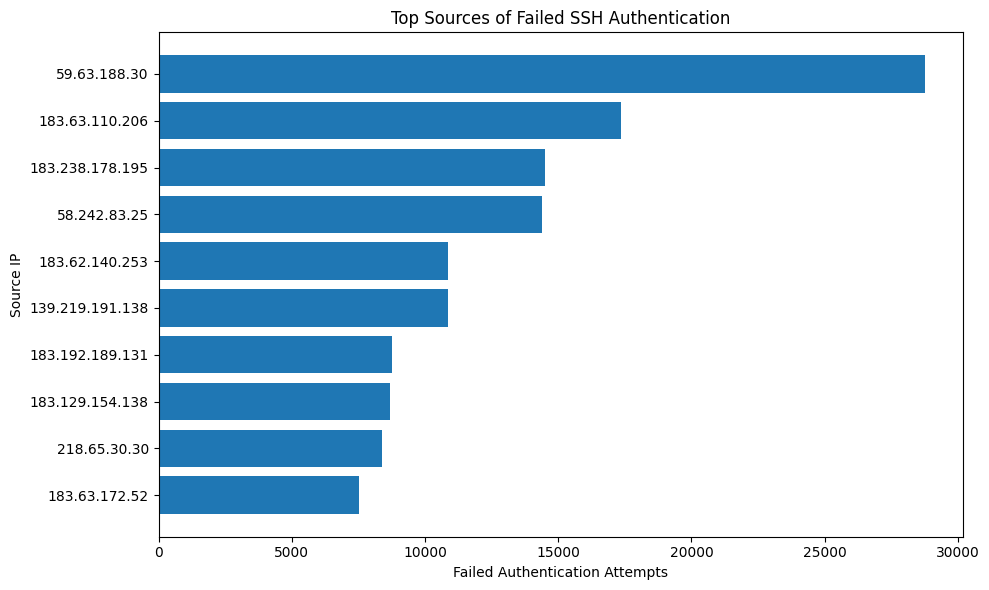

In [49]:
import matplotlib.pyplot as plt

top_failed = [
    ("59.63.188.30", 28766),
    ("183.63.110.206", 17340),
    ("183.238.178.195", 14519),
    ("58.242.83.25", 14383),
    ("183.62.140.253", 10852),
    ("139.219.191.138", 10852),
    ("183.192.189.131", 8755),
    ("183.129.154.138", 8670),
    ("218.65.30.30", 8374),
    ("183.63.172.52", 7506)
]

ips = [x[0] for x in top_failed]
counts = [x[1] for x in top_failed]

plt.figure(figsize=(10, 6))
plt.barh(ips[::-1], counts[::-1])
plt.xlabel("Failed Authentication Attempts")
plt.ylabel("Source IP")
plt.title("Top Sources of Failed SSH Authentication")
plt.tight_layout()
plt.savefig("/content/top_failed_ssh_sources.png", dpi=300)
plt.show()

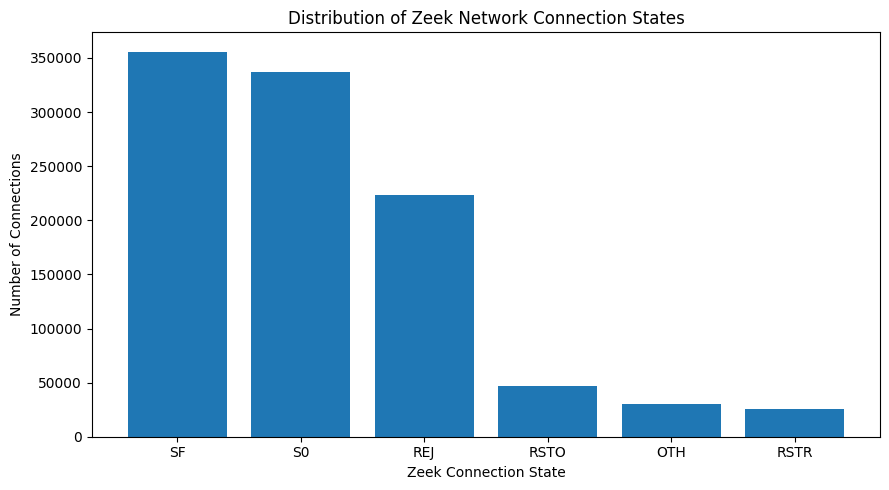

In [50]:
states = ["SF", "S0", "REJ", "RSTO", "OTH", "RSTR"]
counts = [355909, 336963, 223175, 46839, 30240, 25489]

plt.figure(figsize=(9, 5))
plt.bar(states, counts)
plt.xlabel("Zeek Connection State")
plt.ylabel("Number of Connections")
plt.title("Distribution of Zeek Network Connection States")
plt.tight_layout()
plt.savefig("/content/zeek_connection_states.png", dpi=300)
plt.show()